# Imbalance Datasets

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [155]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, 
    n_features=2, 
    n_clusters_per_class=1, 
    n_redundant=0, 
    weights=[0.99], 
    random_state=10
)
X.shape, y.shape

((1000, 2), (1000,))

In [156]:
count = np.sum(y == 0)
count

985

In [157]:
df = pd.DataFrame(X, columns=["x1", "x2"])
df["y"] = y
df.head()

,x1,x2,y
0,1.451220,-1.086705,0
1,2.080290,-0.978084,0
2,1.918052,-1.043149,0
3,1.389333,-1.253164,0
4,-1.479985,-0.316676,1


In [158]:
df[df["y"] == 1].count()

x1    15
x2    15
y     15
dtype: int64

<Axes: xlabel='x1', ylabel='x2'>

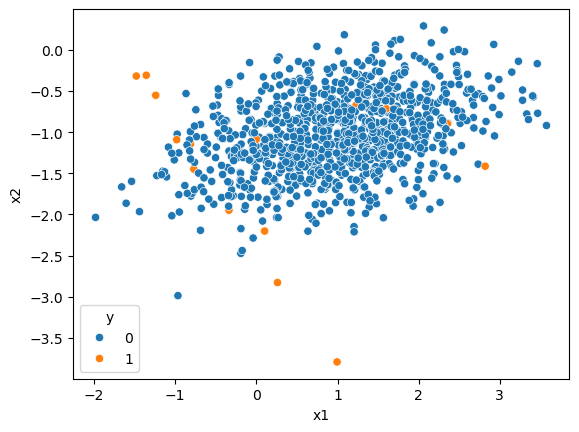

In [159]:
sns.scatterplot(data=df, x="x1", y="x2", hue="y")
# sns.scatterplot(data=df[df["y"] == 1], x="x1", y="x2", label="1")


In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Example data
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [161]:
class_weight = [{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Assuming class_weight is defined earlier, e.g.
# class_weight = 'balanced'

param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'class_weight': class_weight
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'class_weight': class_weight    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'l1_ratio': [0.5, 0.7, 0.9],
        'class_weight': class_weight
    }
]

model = LogisticRegression(max_iter=1000)
grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs = -1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)


Best parameters: {'C': 1, 'class_weight': {0: 50, 1: 10}, 'l1_ratio': 0.7, 'penalty': 'elasticnet', 'solver': 'saga'}


c:\Users\sande\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [163]:
print("Best params:", grid.best_params_)
print("best accuracy", grid.best_score_)


Best params: {'C': 1, 'class_weight': {0: 50, 1: 10}, 'l1_ratio': 0.7, 'penalty': 'elasticnet', 'solver': 'saga'}
best accuracy 0.975


In [164]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = grid.predict(X_test)
score = accuracy_score(y_pred, y_test)
print(score)
print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))


0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.75      0.86        12
           2       0.73      1.00      0.84         8

    accuracy                           0.90        30
   macro avg       0.91      0.92      0.90        30
weighted avg       0.93      0.90      0.90        30

[[10  0  0]
 [ 0  9  3]
 [ 0  0  8]]


# ROC CURVE

In [165]:
from sklearn.metrics import roc_auc_score, roc_curve

In [166]:
dummy_model_prob = [0 for _ in range(len(y_test))]